In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('spin_qubit_results.pkl', 'rb') as f:
    payload = pickle.load(f)

meta    = payload['meta']
results = payload['results']

distances     = meta['distances']
p_mean_values = meta['p_mean_values']
sigma_frac    = meta['sigma_frac']
shots         = meta['shots']
Nkeep         = meta['Nkeep']
num_maps      = meta['num_maps']

print('Loaded results')
print(f'  distances     = {distances}')
print(f'  p_mean_values = {[float(f"{p:.4g}") for p in p_mean_values]}')
print(f'  shots         = {shots}')
print(f'  Nkeep         = {Nkeep}')
print(f'  sigma_frac    = {sigma_frac}')
print(f'  num_maps      = {num_maps}')

Loaded results
  distances     = [3, 5]
  p_mean_values = [0.01, 0.01313, 0.01724, 0.02264, 0.02972, 0.03903, 0.05125, 0.06729, 0.08835, 0.116, 0.1523, 0.2]
  shots         = 10000
  Nkeep         = 32
  sigma_frac    = 0.3
  num_maps      = 3


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

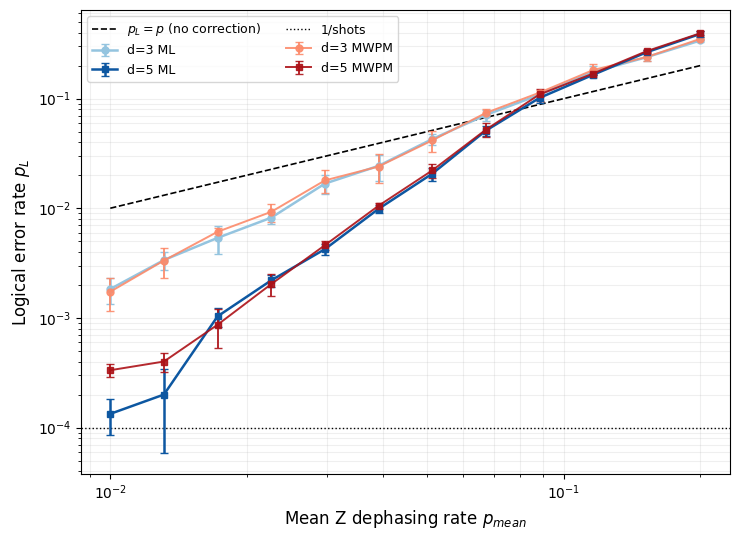

In [3]:
# Plot 1: ML vs MWPM — local Z dephasing
import matplotlib.cm as cm
import math

n = len(distances)
blue_colors = [cm.Blues(0.4 + 0.45 * i / max(n - 1, 1)) for i in range(n)]
red_colors  = [cm.Reds( 0.4 + 0.45 * i / max(n - 1, 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(p_mean_values, p_mean_values, 'k--', linewidth=1.2, label='$p_L = p$ (no correction)')
ax.axhline(y=1/shots, color='k', linestyle=':', linewidth=1.0, label='1/shots')

types = ['o', 's', '^']
for i, d in enumerate(distances):
    r = results[d]
    ax.errorbar(
        p_mean_values, r['peps_local_mean'], yerr=r['peps_local_std'],
        fmt=types[i]+'-', color=blue_colors[i], markersize=5, linewidth=1.8, capsize=3,
        label=f'd={d} ML',
    )
    ax.errorbar(
        p_mean_values, r['mwpm_local_mean'], yerr=r['mwpm_local_std'],
        fmt=types[i]+'-', color=red_colors[i], markersize=5, linewidth=1.4, capsize=3, alpha=0.9,
        label=f'd={d} MWPM',
    )

handles, labels = ax.get_legend_handles_labels()
ncol = 2
nrow = math.ceil(len(handles) / ncol)
order = [(k % nrow) * ncol + (k // nrow) for k in range(len(handles))]
ax.legend([handles[i] for i in order], [labels[i] for i in order], fontsize=9, ncol=ncol)

ax.set_xlabel('Mean Z dephasing rate $p_{mean}$', fontsize=12)
ax.set_ylabel('Logical error rate $p_L$', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.savefig('spin_qubit_peps_vs_mwpm_local.png', dpi=160)
plt.show()

In [4]:
# Summary table
col_w = 12
header = f"{'p_mean':>10}" + ''.join(
    f"{'d='+str(d)+' PEPS':>{col_w}}{'d='+str(d)+' MWPM':>{col_w}}"
    for d in distances
)
print(header)
print('-' * len(header))
for i, p in enumerate(p_mean_values):
    row = f"{p:10.4f}" + ''.join(
        f"{results[d]['peps_local_mean'][i]:{col_w}.4f}"
        f"{results[d]['mwpm_local_mean'][i]:{col_w}.4f}"
        for d in distances
    )
    print(row)

    p_mean    d=3 PEPS    d=3 MWPM    d=5 PEPS    d=5 MWPM
----------------------------------------------------------
    0.0100      0.0018      0.0017      0.0001      0.0003
    0.0131      0.0034      0.0033      0.0002      0.0004
    0.0172      0.0054      0.0061      0.0010      0.0009
    0.0226      0.0082      0.0093      0.0022      0.0020
    0.0297      0.0168      0.0179      0.0042      0.0046
    0.0390      0.0243      0.0240      0.0099      0.0105
    0.0512      0.0427      0.0415      0.0206      0.0221
    0.0673      0.0709      0.0740      0.0510      0.0520
    0.0883      0.1083      0.1132      0.1014      0.1090
    0.1160      0.1748      0.1821      0.1648      0.1692
    0.1523      0.2387      0.2394      0.2648      0.2710
    0.2000      0.3388      0.3509      0.3888      0.3945
